# Tahap 06 — Exploratory Data Analysis Dataset Cleaned Komentar YouTube

## 1. Tujuan Tahap

Tahap ini bertujuan untuk melakukan Exploratory Data Analysis (EDA) terhadap dataset komentar YouTube yang telah melalui proses data cleaning dan text preprocessing awal.

Fokus utama tahap ini adalah memahami karakteristik dataset hasil cleaning, seperti struktur data, kelengkapan data, potensi duplikasi, panjang komentar, distribusi jumlah kata, serta eksplorasi awal terhadap kata dan frasa yang sering muncul.

Tahap ini belum melakukan labeling sentimen, stemming final, stopword removal final, pembobotan TF-IDF, modeling machine learning, evaluasi model, maupun deployment Streamlit.

Dengan demikian, hasil dari tahap ini digunakan sebagai dasar analitis sebelum masuk ke tahap labeling dan pemodelan sentimen pada tahap berikutnya.

## 2. Output yang Dihasilkan

Output yang dihasilkan dari Tahap 06 ini adalah:

1. Notebook EDA dataset cleaned:
   - `notebooks/06_eda_cleaned_text_analysis.ipynb`

2. Ringkasan hasil EDA dalam format CSV:
   - `reports/eda_cleaned_summary_*.csv`

3. Ringkasan struktur dataset:
   - `reports/eda_cleaned_overview_*.csv`

4. Daftar kata paling sering muncul pada `text_clean`:
   - `reports/top_words_cleaned_*.csv`

5. Daftar bigram paling sering muncul pada `text_clean`:
   - `reports/top_bigrams_cleaned_*.csv`

6. Visualisasi sederhana yang ditampilkan di notebook, seperti:
   - Histogram panjang komentar
   - Bar chart top words
   - Bar chart top bigrams

Catatan: Dataset cleaned hanya dibaca dari folder `data/processed/` dan tidak dimodifikasi pada tahap ini.

## 3. Import Library

Pada bagian ini dilakukan import library yang diperlukan untuk membaca dataset, melakukan eksplorasi data, menghitung statistik dasar, membuat visualisasi sederhana, serta menyimpan hasil EDA ke folder `reports/`.

Library yang digunakan masih bersifat eksploratif dan belum digunakan untuk modeling.

In [1]:
# ============================================================
# Tahap 06 - Exploratory Data Analysis Dataset Cleaned
# Import Library
# ============================================================

# Library standar Python
import os
import re
from pathlib import Path
from datetime import datetime
from collections import Counter

# Library pengolahan data
import pandas as pd
import numpy as np

# Library visualisasi
import matplotlib.pyplot as plt

# Pengaturan tampilan dataframe agar lebih nyaman dibaca
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 120)

print("Library berhasil di-import.")

Library berhasil di-import.


## 4. Deteksi Project Root

Notebook ini berada di dalam folder `notebooks/`, sedangkan dataset dan laporan berada pada folder utama project.

Oleh karena itu, perlu dilakukan deteksi project root agar notebook dapat membaca folder `data/processed/` dan menyimpan output ke folder `reports/` secara konsisten.

In [2]:
# ============================================================
# Deteksi Project Root
# ============================================================

current_path = Path.cwd()

# Jika notebook dijalankan dari folder notebooks, maka project root adalah parent folder
if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

# Definisi folder utama project
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

# Membuat folder reports jika belum ada
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Current path       :", current_path)
print("Project root       :", PROJECT_ROOT)
print("Data processed dir :", DATA_PROCESSED_DIR)
print("Reports dir        :", REPORTS_DIR)

Current path       : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\notebooks
Project root       : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis
Data processed dir : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\processed
Reports dir        : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports


## 5. Deteksi Dataset Cleaned Terbaru

Pada bagian ini, notebook akan mendeteksi file dataset cleaned terbaru yang tersimpan di folder `data/processed/`.

Deteksi dilakukan berdasarkan waktu modifikasi file. Hal ini bertujuan agar notebook selalu membaca dataset hasil cleaning terbaru tanpa perlu menuliskan nama file secara manual.

Dataset hanya akan dibaca, tidak diubah.

In [3]:
# ============================================================
# Deteksi Dataset Cleaned Terbaru
# ============================================================

# Validasi keberadaan folder data/processed
if not DATA_PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f"Folder data processed tidak ditemukan: {DATA_PROCESSED_DIR}"
    )

# Mencari file CSV hasil cleaning
# Pola dibuat cukup fleksibel agar dapat menangkap nama file cleaned yang berbeda
cleaned_files = list(DATA_PROCESSED_DIR.glob("*clean*.csv"))

# Jika tidak ditemukan dengan pola clean, cari semua CSV sebagai fallback
if len(cleaned_files) == 0:
    cleaned_files = list(DATA_PROCESSED_DIR.glob("*.csv"))

# Validasi file ditemukan
if len(cleaned_files) == 0:
    raise FileNotFoundError(
        f"Tidak ditemukan file CSV dataset cleaned di folder: {DATA_PROCESSED_DIR}"
    )

# Mengambil file terbaru berdasarkan waktu modifikasi
latest_cleaned_file = max(cleaned_files, key=lambda file: file.stat().st_mtime)

# Informasi file terbaru
latest_modified_time = datetime.fromtimestamp(
    latest_cleaned_file.stat().st_mtime
).strftime("%Y-%m-%d %H:%M:%S")

print("Jumlah file dataset cleaned ditemukan:", len(cleaned_files))
print("File dataset cleaned terbaru:")
print(latest_cleaned_file.name)
print("\nWaktu modifikasi file terbaru:")
print(latest_modified_time)

Jumlah file dataset cleaned ditemukan: 1
File dataset cleaned terbaru:
youtube_comments_cleaned_20260529_150114.csv

Waktu modifikasi file terbaru:
2026-05-29 15:01:14


## 6. Load Dataset Cleaned Secara Aman

Pada bagian ini, dataset cleaned dibaca menggunakan `pandas`.

Dataset hanya dimuat untuk kebutuhan analisis eksploratif. Notebook tidak akan menampilkan API key, tidak membaca file `.env`, dan tidak menampilkan kolom sensitif seperti `author`.

Jika terdapat kolom yang tidak digunakan untuk EDA, kolom tersebut tidak akan ditampilkan pada preview data.

In [4]:
# ============================================================
# Load Dataset Cleaned
# ============================================================

try:
    df_cleaned = pd.read_csv(latest_cleaned_file)
    print("Dataset cleaned berhasil dibaca.")
    print("Nama file:", latest_cleaned_file.name)
    print("Jumlah baris:", df_cleaned.shape[0])
    print("Jumlah kolom:", df_cleaned.shape[1])

except Exception as e:
    raise RuntimeError(f"Gagal membaca dataset cleaned: {e}")

Dataset cleaned berhasil dibaca.
Nama file: youtube_comments_cleaned_20260529_150114.csv
Jumlah baris: 3670
Jumlah kolom: 20


## 7. Validasi Kolom Utama

Pada tahap EDA ini, dua kolom utama yang wajib tersedia adalah:

- `text_original`: teks komentar asli dari YouTube
- `text_clean`: teks hasil cleaning awal

Validasi ini dilakukan untuk memastikan bahwa dataset cleaned siap digunakan untuk analisis eksploratif teks.

In [5]:
# ============================================================
# Validasi Kolom Utama
# ============================================================

required_columns = ["text_original", "text_clean"]

missing_required_columns = [
    col for col in required_columns if col not in df_cleaned.columns
]

if missing_required_columns:
    raise ValueError(
        f"Kolom wajib berikut tidak ditemukan pada dataset cleaned: {missing_required_columns}"
    )

print("Validasi berhasil.")
print("Kolom wajib tersedia:", required_columns)

Validasi berhasil.
Kolom wajib tersedia: ['text_original', 'text_clean']


## 8. Preview Aman Dataset

Preview dataset dilakukan secara terbatas untuk memastikan struktur data terbaca dengan benar.

Kolom `author` tidak ditampilkan. Jika kolom tersebut masih ada pada dataset, kolom tersebut akan dikecualikan dari preview.

In [6]:
# ============================================================
# Preview Aman Dataset
# ============================================================

# Kolom yang tidak ingin ditampilkan
excluded_preview_columns = ["author"]

# Membuat daftar kolom aman untuk preview
safe_preview_columns = [
    col for col in df_cleaned.columns if col not in excluded_preview_columns
]

# Untuk menjaga tampilan tetap ringkas, batasi jumlah kolom yang ditampilkan
priority_columns = [
    "comment_id",
    "video_id",
    "text_original",
    "text_clean",
    "published_at",
    "like_count"
]

# Ambil hanya kolom prioritas yang benar-benar tersedia
available_preview_columns = [
    col for col in priority_columns if col in safe_preview_columns
]

# Jika kolom prioritas tidak tersedia, gunakan kolom aman yang ada
if len(available_preview_columns) == 0:
    available_preview_columns = safe_preview_columns[:8]

df_cleaned[available_preview_columns].head(5)

,comment_id,video_id,text_original,text_clean,published_at,like_count
0,Ugzo_OAorVrtNPFL3cF4AaABAg,sB7fSPbYFJg,"gue kira di upload 10 jam yg lalu,ternyata 10 tahun yg lalu😂",saya kira di upload 10 jam yang lalu ternyata 10 tahun yang lalu,2026-05-24 01:37:15+00:00,560
1,Ugx2WJ9HFPUNRPaOxON4AaABAg,sB7fSPbYFJg,"Timing nya gabisa lebih pas dari ini😭🙏\nNyentuh Rp.25.000,00 Masih Aman Indonesia😎👌",timing nya gabisa lebih pas dari ini nyentuh rupiah 25 000 00 masih aman indonesia,2026-05-22 13:31:00+00:00,570
2,UgwyjT6JiPsbjsMoUqR4AaABAg,sB7fSPbYFJg,Algoritma YouTube cukup mengerikan 🥀,algoritma youtube cukup mengerikan,2026-05-24 09:42:48+00:00,271
3,UgwN7TGK6eU5papwnNZ4AaABAg,sB7fSPbYFJg,dyeem 10 year ago lewat beranda kuhh pas bgett;(((,dyeem 10 year ago lewat beranda kuhh pas bgett,2026-05-21 06:57:48+00:00,321
4,UgzSaWu-A-vsRbjSc6B4AaABAg,sB7fSPbYFJg,Algoritma YouTube lebih mengerikan daripada Pria Solo☠️,algoritma youtube lebih mengerikan daripada pria solo,2026-05-23 17:47:36+00:00,92


## 9. Cek Struktur Dataset Awal

Pada bagian ini dilakukan pemeriksaan struktur dataset, meliputi jumlah baris, jumlah kolom, nama kolom, dan tipe data.

Pemeriksaan ini penting untuk memastikan dataset sudah konsisten sebelum dilakukan analisis statistik panjang teks dan frekuensi kata.

In [7]:
# ============================================================
# Cek Struktur Dataset
# ============================================================

print("Jumlah baris:", df_cleaned.shape[0])
print("Jumlah kolom:", df_cleaned.shape[1])

print("\nDaftar kolom:")
for idx, col in enumerate(df_cleaned.columns, start=1):
    print(f"{idx}. {col}")

print("\nInformasi tipe data:")
df_cleaned.info()

Jumlah baris: 3670
Jumlah kolom: 20

Daftar kolom:
1. video_id
2. video_title
3. video_url
4. channel_title
5. video_published_at
6. comment_id
7. published_at
8. comment_updated_at
9. text_original
10. like_count
11. reply_count
12. crawl_timestamp
13. source_file
14. text_original_char_count
15. text_original_word_count
16. text_clean
17. text_clean_char_count
18. text_clean_word_count
19. char_count_reduction
20. word_count_reduction

Informasi tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 3670 entries, 0 to 3669
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   video_id                  3670 non-null   str  
 1   video_title               3670 non-null   str  
 2   video_url                 3670 non-null   str  
 3   channel_title             3670 non-null   str  
 4   video_published_at        3670 non-null   str  
 5   comment_id                3670 non-null   str  
 6   published_at

## 10. Analisis Missing Value

Pada bagian ini dilakukan pemeriksaan missing value pada dataset cleaned.

Analisis ini bertujuan untuk memastikan apakah masih terdapat nilai kosong pada kolom-kolom penting setelah proses cleaning, khususnya pada kolom `text_original` dan `text_clean`.

Tahap ini hanya melakukan pemeriksaan, tidak melakukan imputasi atau penghapusan data.

In [8]:
# ============================================================
# Analisis Missing Value
# ============================================================

missing_summary = pd.DataFrame({
    "column": df_cleaned.columns,
    "missing_count": df_cleaned.isna().sum().values,
    "missing_percentage": (df_cleaned.isna().sum().values / len(df_cleaned) * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="missing_count", ascending=False
).reset_index(drop=True)

missing_summary

,column,missing_count,missing_percentage
0,video_id,0,0.0
1,video_title,0,0.0
2,video_url,0,0.0
3,channel_title,0,0.0
4,video_published_at,0,0.0
5,comment_id,0,0.0
6,published_at,0,0.0
7,comment_updated_at,0,0.0
8,text_original,0,0.0
9,like_count,0,0.0


## 11. Pemeriksaan Duplikasi

Pada bagian ini dilakukan pemeriksaan duplikasi terhadap dua aspek utama:

1. Duplikasi berdasarkan `comment_id`, jika kolom tersebut tersedia.
2. Duplikasi berdasarkan `text_clean`.

Duplikasi `comment_id` menunjukkan kemungkinan komentar yang sama tercatat lebih dari satu kali. Sementara itu, duplikasi `text_clean` dapat menunjukkan adanya komentar dengan isi yang identik setelah proses cleaning.

Tahap ini hanya menghitung duplikasi dan tidak menghapus data.

In [9]:
# ============================================================
# Pemeriksaan Duplikasi
# ============================================================

# Duplikasi comment_id
if "comment_id" in df_cleaned.columns:
    duplicate_comment_id_count = df_cleaned.duplicated(subset=["comment_id"]).sum()
else:
    duplicate_comment_id_count = np.nan

# Duplikasi text_clean
duplicate_text_clean_count = df_cleaned.duplicated(subset=["text_clean"]).sum()

duplicate_summary = pd.DataFrame({
    "metric": [
        "duplicate_comment_id",
        "duplicate_text_clean"
    ],
    "value": [
        duplicate_comment_id_count,
        duplicate_text_clean_count
    ]
})

duplicate_summary

,metric,value
0,duplicate_comment_id,0
1,duplicate_text_clean,9


## 12. Statistik Panjang Komentar

Pada bagian ini dilakukan analisis statistik panjang komentar berdasarkan:

1. Jumlah karakter pada `text_original`.
2. Jumlah karakter pada `text_clean`.
3. Jumlah kata pada `text_original`.
4. Jumlah kata pada `text_clean`.

Analisis ini berguna untuk memahami apakah komentar dalam dataset cenderung pendek, sedang, atau panjang. Informasi ini juga penting sebagai dasar sebelum masuk ke tahap representasi teks dan modeling pada tahap berikutnya.

In [10]:
# ============================================================
# Statistik Panjang Komentar
# ============================================================

# Membuat series sementara tanpa mengubah file dataset cleaned
text_original_series = df_cleaned["text_original"].fillna("").astype(str)
text_clean_series = df_cleaned["text_clean"].fillna("").astype(str)

# Menghitung panjang karakter
original_char_length = text_original_series.str.len()
clean_char_length = text_clean_series.str.len()

# Menghitung jumlah kata
original_word_count = text_original_series.str.split().str.len()
clean_word_count = text_clean_series.str.split().str.len()

length_stats = pd.DataFrame({
    "metric": [
        "original_char_length",
        "clean_char_length",
        "original_word_count",
        "clean_word_count"
    ],
    "min": [
        original_char_length.min(),
        clean_char_length.min(),
        original_word_count.min(),
        clean_word_count.min()
    ],
    "mean": [
        original_char_length.mean(),
        clean_char_length.mean(),
        original_word_count.mean(),
        clean_word_count.mean()
    ],
    "median": [
        original_char_length.median(),
        clean_char_length.median(),
        original_word_count.median(),
        clean_word_count.median()
    ],
    "max": [
        original_char_length.max(),
        clean_char_length.max(),
        original_word_count.max(),
        clean_word_count.max()
    ]
})

length_stats["mean"] = length_stats["mean"].round(2)

length_stats

,metric,min,mean,median,max
0,original_char_length,5,110.30,66.0,2457
1,clean_char_length,5,107.79,65.0,2344
2,original_word_count,1,16.98,11.0,328
3,clean_word_count,1,17.05,11.0,324


## 13. Visualisasi Distribusi Panjang Komentar

Pada bagian ini dibuat visualisasi distribusi panjang komentar berdasarkan:

1. Jumlah karakter pada `text_clean`.
2. Jumlah kata pada `text_clean`.

Visualisasi ini membantu melihat sebaran panjang komentar, apakah mayoritas komentar pendek, sedang, atau terdapat komentar yang sangat panjang.

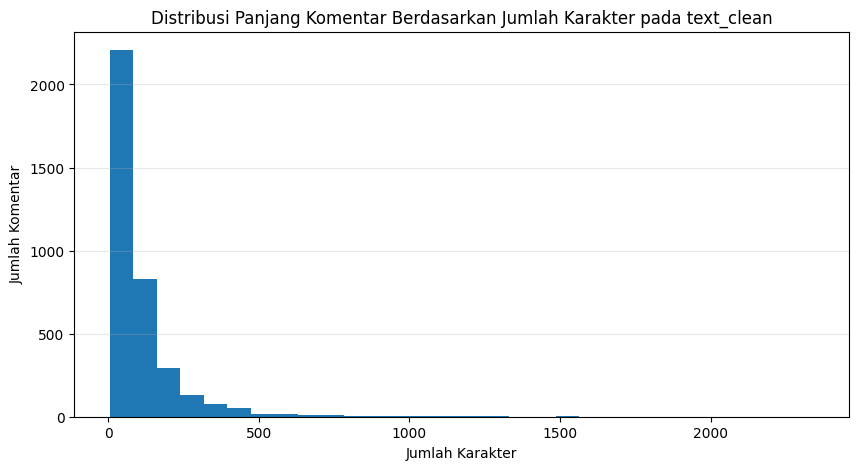

In [11]:
# ============================================================
# Histogram Distribusi Panjang Karakter text_clean
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(clean_char_length, bins=30)
plt.title("Distribusi Panjang Komentar Berdasarkan Jumlah Karakter pada text_clean")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Jumlah Komentar")
plt.grid(axis="y", alpha=0.3)
plt.show()

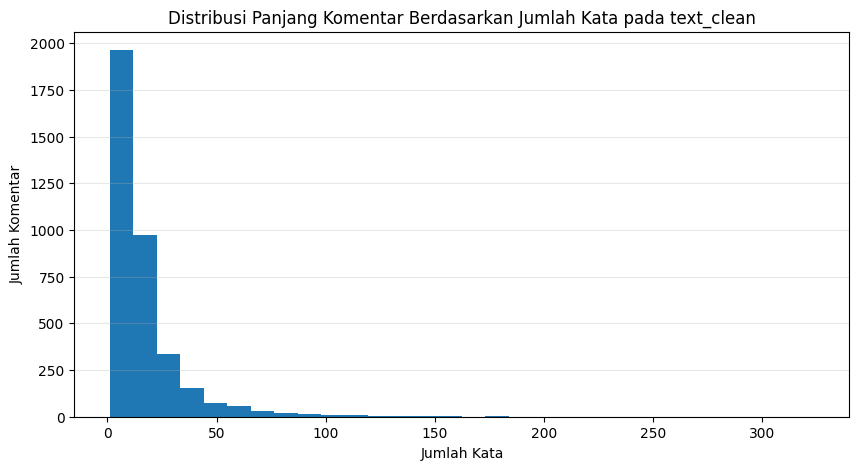

In [13]:
# ============================================================
# Histogram Distribusi Jumlah Kata text_clean
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(clean_word_count, bins=30)
plt.title("Distribusi Panjang Komentar Berdasarkan Jumlah Kata pada text_clean")
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Komentar")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 14. Top Words pada text_clean

Pada bagian ini dilakukan eksplorasi kata yang paling sering muncul pada kolom `text_clean`.

Stopwords sederhana digunakan hanya untuk kebutuhan eksplorasi frekuensi kata, bukan sebagai pipeline preprocessing final untuk modeling.

Dengan demikian, daftar stopwords pada bagian ini tidak dianggap sebagai keputusan final untuk tahap machine learning.

In [14]:
# ============================================================
# Top Words pada text_clean
# ============================================================

# Stopwords sederhana untuk EDA frekuensi kata
# Catatan: ini bukan stopwords final untuk pipeline modeling
simple_stopwords = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan",
    "atau", "pada", "karena", "kalau", "kalo", "jadi", "aja", "saja",
    "ya", "ga", "gak", "nggak", "tidak", "tak", "ada", "apa", "bisa",
    "dalam", "akan", "juga", "sudah", "belum", "lebih", "lagi",
    "lah", "pun", "nya", "si", "para", "kok", "mah", "dong", "deh",
    "the", "a", "an", "is", "are", "to", "of", "in", "on", "for", "and"
}

def tokenize_for_eda(text):
    """
    Fungsi tokenisasi sederhana untuk kebutuhan EDA.
    Fungsi ini bukan preprocessing final untuk modeling.
    """
    text = str(text).lower()
    tokens = text.split()
    
    # Ambil token alfabetik atau alfanumerik sederhana
    tokens = [
        token.strip()
        for token in tokens
        if len(token.strip()) > 1 and token.strip() not in simple_stopwords
    ]
    
    return tokens

# Menggabungkan seluruh token dari text_clean
all_tokens = []

for text in text_clean_series:
    all_tokens.extend(tokenize_for_eda(text))

# Menghitung frekuensi kata
word_counter = Counter(all_tokens)

top_words_df = pd.DataFrame(
    word_counter.most_common(30),
    columns=["word", "frequency"]
)

top_words_df

,word,frequency
0,rupiah,736
1,indonesia,535
2,kita,524
3,negara,494
4,saya,399
5,uang,340
6,ekonomi,322
7,tapi,294
8,dollar,287
9,dolar,281


## 15. Visualisasi Top Words

Visualisasi bar chart digunakan untuk mempermudah pembacaan kata-kata yang paling sering muncul pada `text_clean`.

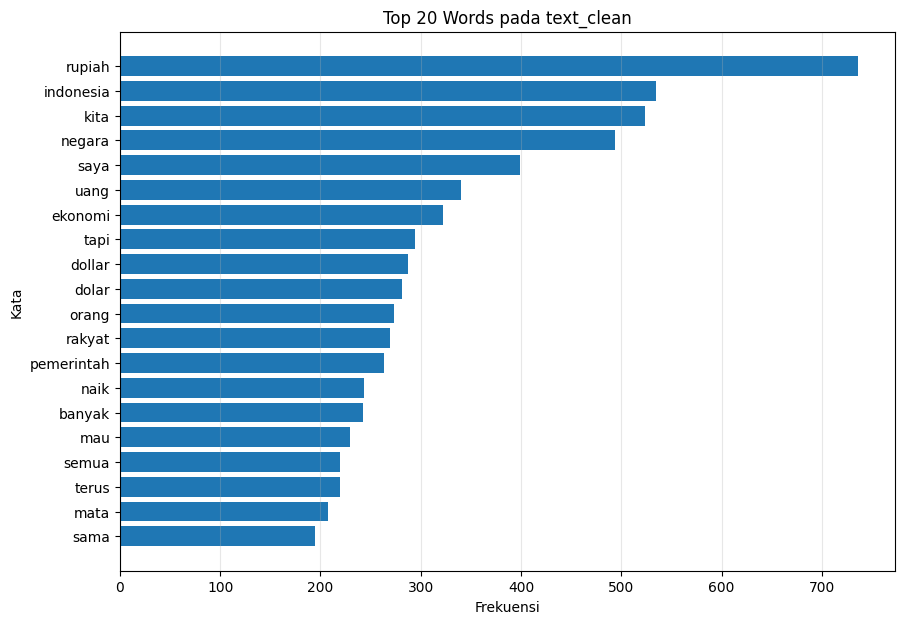

In [15]:
# ============================================================
# Bar Chart Top Words
# ============================================================

top_n_words = 20
top_words_plot = top_words_df.head(top_n_words).sort_values(
    by="frequency", ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(top_words_plot["word"], top_words_plot["frequency"])
plt.title(f"Top {top_n_words} Words pada text_clean")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 16. Top Bigrams pada text_clean

Bigram adalah pasangan dua kata yang muncul secara berurutan.

Analisis bigram digunakan untuk memahami frasa yang sering muncul dalam komentar. Dibandingkan single word, bigram dapat memberikan konteks yang lebih baik, misalnya frasa seperti `harga naik`, `nilai rupiah`, atau `daya beli`.

Stopwords sederhana tetap hanya digunakan untuk eksplorasi frekuensi, bukan sebagai pipeline final.

In [16]:
# ============================================================
# Top Bigrams pada text_clean
# ============================================================

def generate_bigrams(tokens):
    """
    Membuat pasangan dua kata berurutan dari daftar token.
    """
    return list(zip(tokens, tokens[1:]))

all_bigrams = []

for text in text_clean_series:
    tokens = tokenize_for_eda(text)
    all_bigrams.extend(generate_bigrams(tokens))

bigram_counter = Counter(all_bigrams)

top_bigrams_df = pd.DataFrame(
    [
        (" ".join(bigram), freq)
        for bigram, freq in bigram_counter.most_common(30)
    ],
    columns=["bigram", "frequency"]
)

top_bigrams_df

,bigram,frequency
0,mata uang,169
1,rupiah melemah,93
2,luar negeri,66
3,nilai tukar,54
4,orang desa,48
5,daya beli,48
6,negara lain,40
7,pake dollar,38
8,ekonomi indonesia,37
9,omon omon,36


## 17. Visualisasi Top Bigrams

Visualisasi bar chart digunakan untuk menampilkan bigram yang paling sering muncul pada `text_clean`.

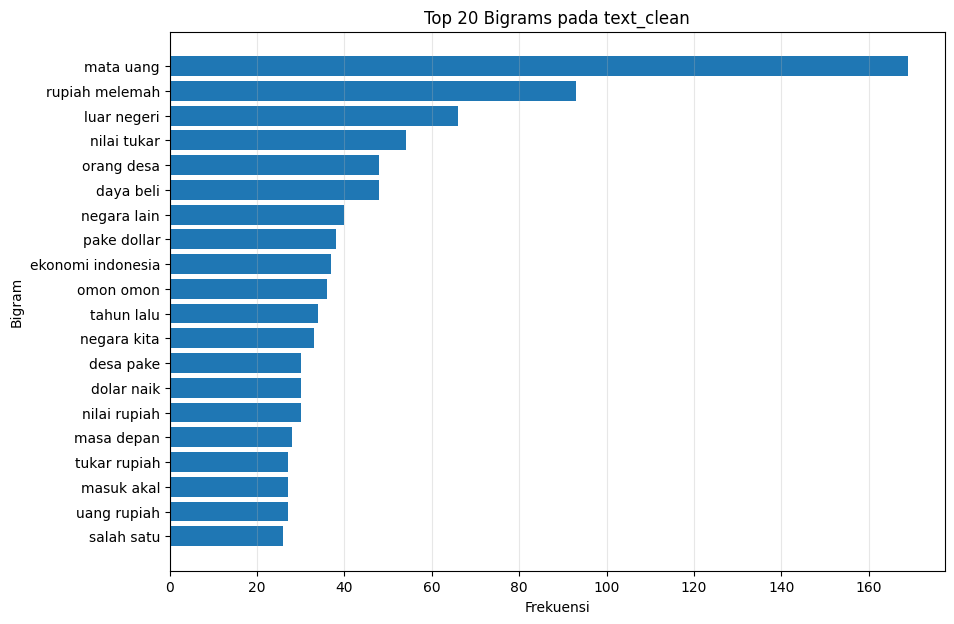

In [17]:
# ============================================================
# Bar Chart Top Bigrams
# ============================================================

top_n_bigrams = 20
top_bigrams_plot = top_bigrams_df.head(top_n_bigrams).sort_values(
    by="frequency", ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(top_bigrams_plot["bigram"], top_bigrams_plot["frequency"])
plt.title(f"Top {top_n_bigrams} Bigrams pada text_clean")
plt.xlabel("Frekuensi")
plt.ylabel("Bigram")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 18. Simpan Ringkasan EDA ke Folder reports

Pada bagian ini, hasil EDA disimpan ke folder `reports/`.

File yang disimpan hanya berupa ringkasan agregat dan daftar frekuensi kata/frasa. Dataset komentar asli dan dataset cleaned tidak disalin atau dipublikasikan dari notebook ini.

In [18]:
# ============================================================
# Simpan Ringkasan EDA ke Folder reports
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Ringkasan umum dataset
eda_summary = pd.DataFrame({
    "metric": [
        "source_file",
        "total_rows",
        "total_columns",
        "missing_text_original",
        "missing_text_clean",
        "duplicate_comment_id",
        "duplicate_text_clean",
        "original_char_mean",
        "clean_char_mean",
        "original_word_mean",
        "clean_word_mean",
        "original_char_median",
        "clean_char_median",
        "original_word_median",
        "clean_word_median"
    ],
    "value": [
        latest_cleaned_file.name,
        df_cleaned.shape[0],
        df_cleaned.shape[1],
        df_cleaned["text_original"].isna().sum(),
        df_cleaned["text_clean"].isna().sum(),
        duplicate_comment_id_count,
        duplicate_text_clean_count,
        round(original_char_length.mean(), 2),
        round(clean_char_length.mean(), 2),
        round(original_word_count.mean(), 2),
        round(clean_word_count.mean(), 2),
        original_char_length.median(),
        clean_char_length.median(),
        original_word_count.median(),
        clean_word_count.median()
    ]
})

# Ringkasan struktur dataset
eda_overview = pd.DataFrame({
    "column": df_cleaned.columns,
    "dtype": df_cleaned.dtypes.astype(str).values,
    "missing_count": df_cleaned.isna().sum().values,
    "missing_percentage": (df_cleaned.isna().sum().values / len(df_cleaned) * 100).round(2),
    "unique_count": df_cleaned.nunique(dropna=True).values
})

# Path output
eda_summary_path = REPORTS_DIR / f"eda_cleaned_summary_{timestamp}.csv"
eda_overview_path = REPORTS_DIR / f"eda_cleaned_overview_{timestamp}.csv"
top_words_path = REPORTS_DIR / f"top_words_cleaned_{timestamp}.csv"
top_bigrams_path = REPORTS_DIR / f"top_bigrams_cleaned_{timestamp}.csv"

# Simpan file CSV
eda_summary.to_csv(eda_summary_path, index=False, encoding="utf-8-sig")
eda_overview.to_csv(eda_overview_path, index=False, encoding="utf-8-sig")
top_words_df.to_csv(top_words_path, index=False, encoding="utf-8-sig")
top_bigrams_df.to_csv(top_bigrams_path, index=False, encoding="utf-8-sig")

print("File ringkasan EDA berhasil disimpan:")
print("-", eda_summary_path.name)
print("-", eda_overview_path.name)
print("-", top_words_path.name)
print("-", top_bigrams_path.name)

File ringkasan EDA berhasil disimpan:
- eda_cleaned_summary_20260529_152256.csv
- eda_cleaned_overview_20260529_152256.csv
- top_words_cleaned_20260529_152256.csv
- top_bigrams_cleaned_20260529_152256.csv


## 19. Simpan Visualisasi EDA ke Folder reports

Selain ditampilkan di notebook, visualisasi EDA juga disimpan dalam format PNG ke folder `reports/`.

Visualisasi yang disimpan meliputi:

1. Distribusi panjang karakter komentar.
2. Distribusi jumlah kata komentar.
3. Top words.
4. Top bigrams.

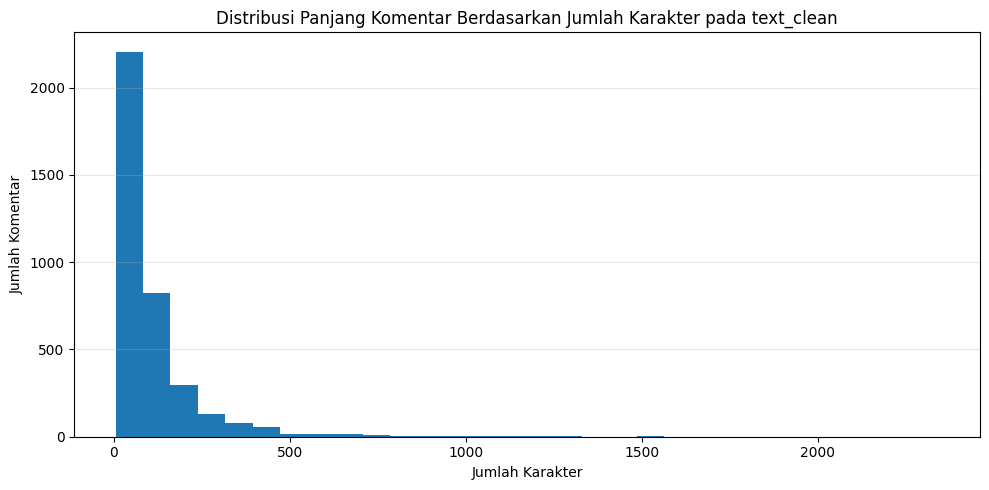

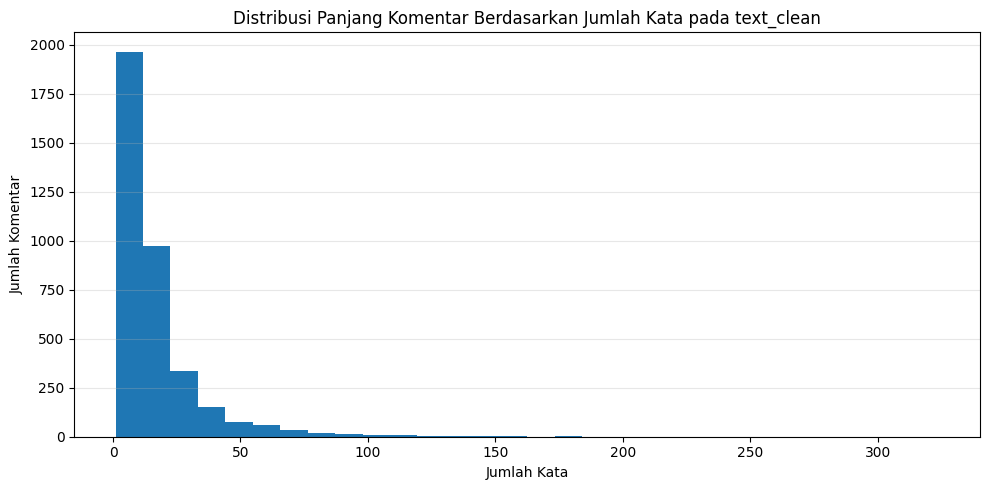

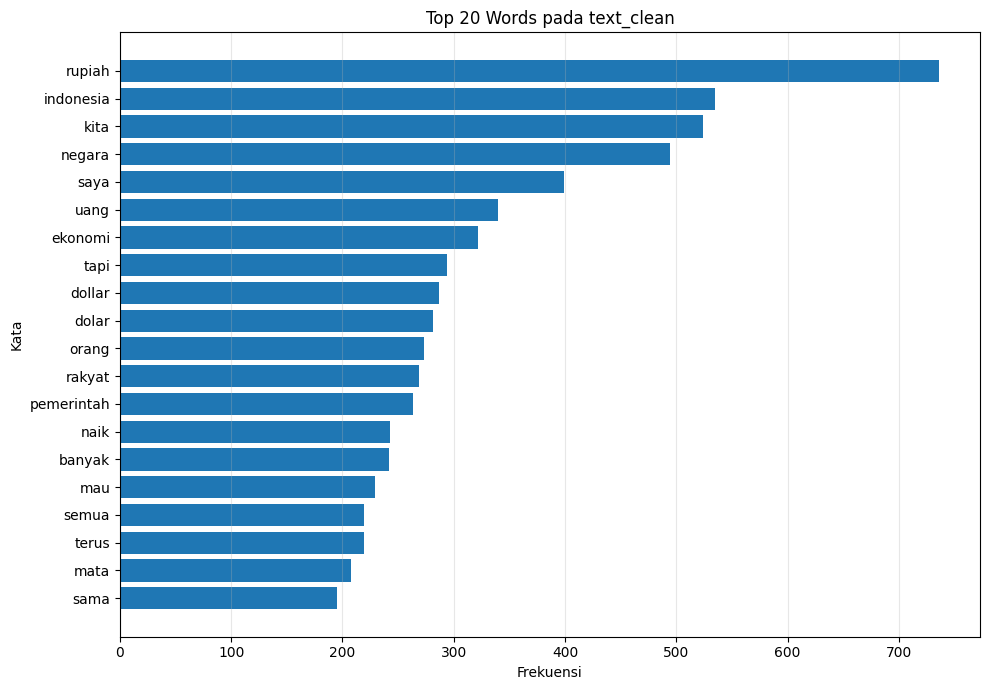

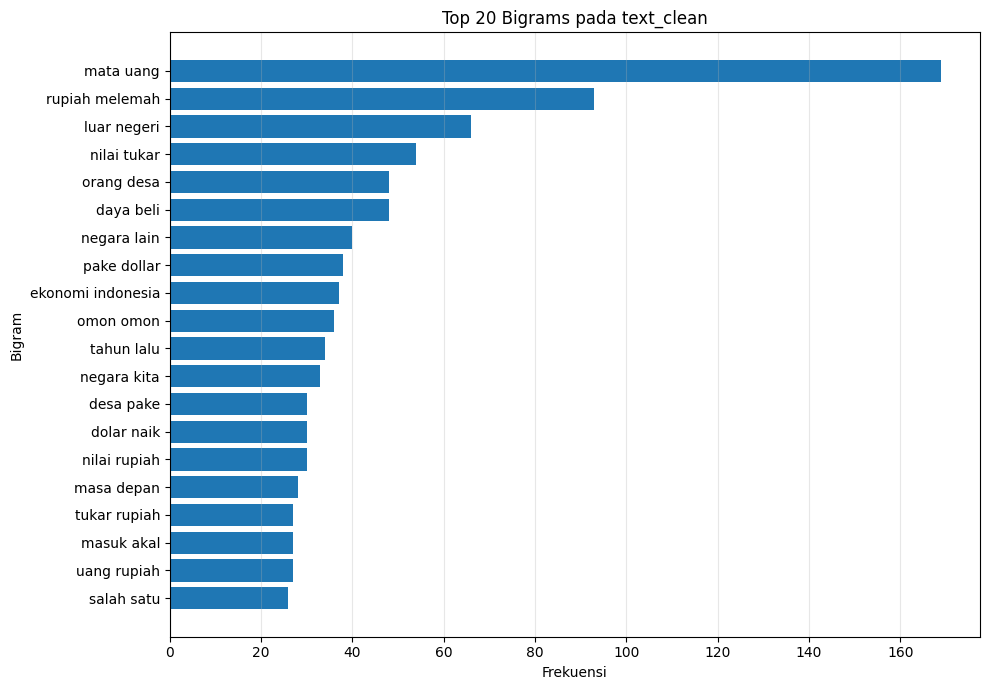

File visualisasi EDA berhasil disimpan:
- eda_hist_clean_char_length_20260529_152256.png
- eda_hist_clean_word_count_20260529_152256.png
- eda_top_words_20260529_152256.png
- eda_top_bigrams_20260529_152256.png


In [19]:
# ============================================================
# Simpan Visualisasi EDA ke Folder reports
# ============================================================

# 1. Histogram panjang karakter
char_hist_path = REPORTS_DIR / f"eda_hist_clean_char_length_{timestamp}.png"

plt.figure(figsize=(10, 5))
plt.hist(clean_char_length, bins=30)
plt.title("Distribusi Panjang Komentar Berdasarkan Jumlah Karakter pada text_clean")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Jumlah Komentar")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(char_hist_path, dpi=300)
plt.show()

# 2. Histogram jumlah kata
word_hist_path = REPORTS_DIR / f"eda_hist_clean_word_count_{timestamp}.png"

plt.figure(figsize=(10, 5))
plt.hist(clean_word_count, bins=30)
plt.title("Distribusi Panjang Komentar Berdasarkan Jumlah Kata pada text_clean")
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Komentar")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(word_hist_path, dpi=300)
plt.show()

# 3. Bar chart top words
top_words_chart_path = REPORTS_DIR / f"eda_top_words_{timestamp}.png"

plt.figure(figsize=(10, 7))
plt.barh(top_words_plot["word"], top_words_plot["frequency"])
plt.title(f"Top {top_n_words} Words pada text_clean")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(top_words_chart_path, dpi=300)
plt.show()

# 4. Bar chart top bigrams
top_bigrams_chart_path = REPORTS_DIR / f"eda_top_bigrams_{timestamp}.png"

plt.figure(figsize=(10, 7))
plt.barh(top_bigrams_plot["bigram"], top_bigrams_plot["frequency"])
plt.title(f"Top {top_n_bigrams} Bigrams pada text_clean")
plt.xlabel("Frekuensi")
plt.ylabel("Bigram")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(top_bigrams_chart_path, dpi=300)
plt.show()

print("File visualisasi EDA berhasil disimpan:")
print("-", char_hist_path.name)
print("-", word_hist_path.name)
print("-", top_words_chart_path.name)
print("-", top_bigrams_chart_path.name)

## 20. Kesimpulan Sementara

Berdasarkan hasil Exploratory Data Analysis terhadap dataset cleaned, dapat disimpulkan beberapa hal berikut:

1. Dataset cleaned berhasil dimuat dari folder `data/processed/` tanpa mengubah isi file sumber.
2. Kolom utama `text_original` dan `text_clean` tersedia sehingga dataset dapat digunakan untuk analisis teks lanjutan.
3. Pemeriksaan missing value dilakukan untuk memastikan kelengkapan data setelah proses cleaning.
4. Pemeriksaan duplikasi dilakukan terhadap `comment_id` dan `text_clean` untuk memahami potensi data berulang.
5. Statistik panjang komentar menunjukkan karakteristik umum komentar YouTube berdasarkan jumlah karakter dan jumlah kata.
6. Visualisasi distribusi panjang komentar membantu memahami apakah komentar cenderung pendek, sedang, atau panjang.
7. Analisis top words dan top bigrams memberikan gambaran awal mengenai kata dan frasa dominan dalam komentar.
8. Seluruh hasil EDA disimpan ke folder `reports/` dalam bentuk ringkasan CSV dan visualisasi PNG.

Tahap ini belum melakukan labeling sentimen, stemming final, stopword removal final, TF-IDF, modeling, evaluasi model, maupun deployment Streamlit.

Hasil dari tahap ini akan digunakan sebagai dasar untuk tahap berikutnya, yaitu persiapan labeling sentimen secara lebih terarah.

## 21. Validasi File Output

Pada bagian ini dilakukan validasi sederhana untuk memastikan file hasil EDA sudah tersimpan di folder `reports/`.

In [20]:
# ============================================================
# Validasi File Output Reports
# ============================================================

expected_report_files = [
    eda_summary_path,
    eda_overview_path,
    top_words_path,
    top_bigrams_path,
    char_hist_path,
    word_hist_path,
    top_words_chart_path,
    top_bigrams_chart_path
]

for file_path in expected_report_files:
    status = "ADA" if file_path.exists() else "TIDAK ADA"
    print(f"{status} - {file_path.name}")

ADA - eda_cleaned_summary_20260529_152256.csv
ADA - eda_cleaned_overview_20260529_152256.csv
ADA - top_words_cleaned_20260529_152256.csv
ADA - top_bigrams_cleaned_20260529_152256.csv
ADA - eda_hist_clean_char_length_20260529_152256.png
ADA - eda_hist_clean_word_count_20260529_152256.png
ADA - eda_top_words_20260529_152256.png
ADA - eda_top_bigrams_20260529_152256.png
